In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from polylex_chatbot.constants import DICT_METRIC_LABELS

In [2]:
df_stats_dev_baseline = pd.read_csv(
    "../../evaluations/20260706_last_corpus/20260712_baseline_collection/all_baseline_results/df_stats.csv", index_col=0)
df_stats_dev_optimal = pd.read_csv(
    "../../evaluations/20260706_last_corpus/20260706_last_collection/generation_mistral_modular_context_item_referenced_mistral_judge/df_stats.csv", index_col=0)
df_stats_test_baseline = pd.read_csv(
    "../../evaluations/20260706_last_corpus/20260712_baseline_collection/test_dataset_baseline_rag_system/df_stats.csv", index_col=0)
df_stats_test_optimal = pd.read_csv(
    "../../evaluations/20260706_last_corpus/20260706_last_collection/test_dataset_optimal_rag_system/df_stats.csv", index_col=0)

stats_results = {
    "Dev — Baseline": df_stats_dev_baseline,
    "Dev — Optimal": df_stats_dev_optimal,
    "Test — Baseline": df_stats_test_baseline,
    "Test — Optimal": df_stats_test_optimal
}

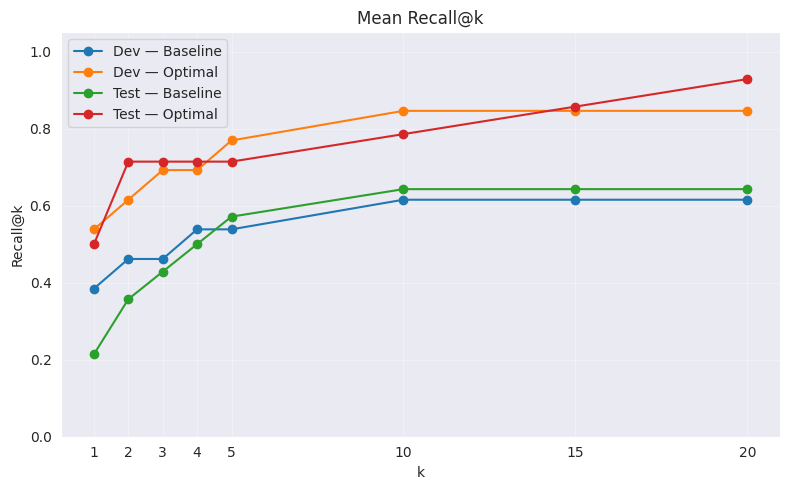

In [3]:
plt.figure(figsize=(8, 5))

all_k = set()

for label, df in stats_results.items():
    recall_cols = [col for col in df.columns if re.match(r"hit_at_\d+$", col)]

    recall_cols = sorted(recall_cols, key=lambda col: int(col.split("_")[-1]))

    recall_df = pd.DataFrame({
        "k": [int(col.split("_")[-1]) for col in recall_cols],
        "mean_recall": [df.loc["mean", col] for col in recall_cols]
    })

    all_k.update(recall_df["k"])

    plt.plot(
        recall_df["k"],
        recall_df["mean_recall"],
        marker="o",
        label=label
    )

plt.xlabel("k")
plt.ylabel("Recall@k")
plt.title("Mean Recall@k")
plt.xticks(sorted(all_k))
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
def filter_and_reorder_df(df):
    cols_reordered = ["mrr_doc", "Context Relevance (Contextrelevance-Langfuse)", "Groundedness (Faithfulness-RAGAS)", "Answer Relevance (Relevance-Langfuse)", "Answer Correctness - RAGAS", "semantic_similarity", "len_answers_quality", "chrf_score"]
    df_filtred = df.copy()
    df_filtred.drop(
        columns=["hit_at_1", "hit_at_2", "hit_at_3", "hit_at_4", "hit_at_5", "hit_at_10", "hit_at_15", "hit_at_20", "ratio_correct_docs"],
        inplace=True
    )
    return df_filtred[cols_reordered]

In [5]:
stats_results_filtred = {
    "Dev — Baseline": filter_and_reorder_df(df_stats_dev_baseline),
    "Dev — Optimal": filter_and_reorder_df(df_stats_dev_optimal),
    "Test — Baseline": filter_and_reorder_df(df_stats_test_baseline),
    "Test — Optimal": filter_and_reorder_df(df_stats_test_optimal)
}

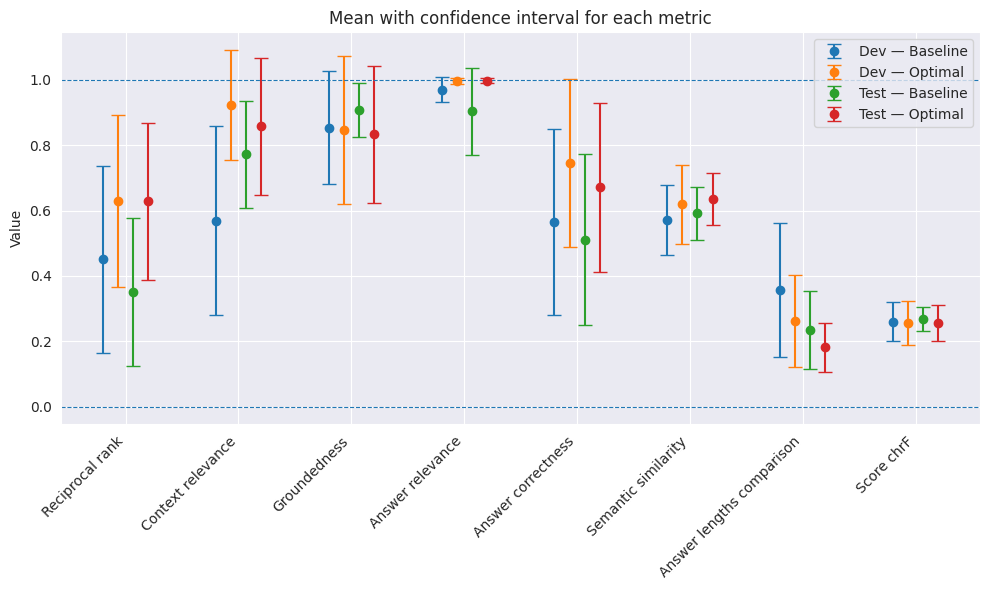

In [6]:
df_ref = stats_results_filtred.get("Dev — Baseline")
spacing = 2.5
group_width = 1.0

x = np.arange(len(df_ref.columns)) * spacing
x_labels = [DICT_METRIC_LABELS[col] for col in df_ref.columns]
n_results = len(stats_results_filtred)
offsets = np.linspace(-group_width / 2, group_width / 2, n_results)

plt.figure(figsize=(10, 6))

for offset, (label, df_stats) in zip(offsets, stats_results_filtred.items()):
    means = df_stats.loc["mean"]
    ci_lower = df_stats.loc["ci_lower_bound"]
    ci_upper = df_stats.loc["ci_upper_bound"]
    yerr_lower = means - ci_lower
    yerr_upper = ci_upper - means

    plt.errorbar(
        x + offset,
        means.values,
        yerr=[yerr_lower, yerr_upper],
        fmt="o",
        capsize=5,
        linewidth=1.5,
        label=label
    )

plt.xticks(x, x_labels, rotation=45, ha="right")
plt.ylabel("Value")
plt.title("Mean with confidence interval for each metric")
plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axhline(1, linestyle="--", linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
questions_ref = pd.read_csv("../../private_questions_dataset.csv")
questions_ref["id_dataset_splitted"] = (
    questions_ref
    .groupby("Dataset", sort=False)
    .cumcount()
    .add(1)
)
question_to_id = (
    questions_ref
    .drop_duplicates(subset=["Dataset", "Question"])
    .set_index(["Dataset", "Question"])["id_dataset_splitted"]
)

In [8]:
def add_question_id_and_reorder_df(df, dataset):
    df_cleaned = df.copy()

    keys = pd.MultiIndex.from_arrays(
        [
            pd.Series(dataset, index=df_cleaned.index),
            df_cleaned["question"]
        ],
        names=["Dataset", "Question"]
    )

    df_cleaned.insert(
        0,
        "id_in_dataset",
        question_to_id.reindex(keys).to_numpy()
    )

    return df_cleaned

In [9]:
cols = [
    "mrr_doc",
    "Context Relevance (Contextrelevance-Langfuse)",
    "Answer Correctness - RAGAS",
    "semantic_similarity",
    "Groundedness (Faithfulness-RAGAS)",
    "Answer Relevance (Relevance-Langfuse)",
    "len_answers_quality",
    "chrf_score"
]

def plot_metrics_for_split(dataset_type, baseline_df, optimal_df):
    baseline = baseline_df.copy()
    optimal = optimal_df.copy()

    baseline["System"] = "Baseline"
    optimal["System"] = "Optimal"

    df_results = pd.concat(
        [baseline, optimal],
        ignore_index=True
    )

    system_order = ["Baseline", "Optimal"]

    hue_order = sorted(df_results["id_in_dataset"].unique())
    palette_values = sns.color_palette("husl", n_colors=len(hue_order))
    question_palette = dict(zip(hue_order, palette_values))

    fig, axes = plt.subplots(4, 2, figsize=(12, 16), sharex=False)
    axes = axes.flatten()

    legend_handles = None
    legend_labels = None

    for ax, col in zip(axes, cols):
        sns.boxplot(
            data=df_results,
            x="System",
            y=col,
            order=system_order,
            showfliers=False,
            width=0.4,
            ax=ax
        )

        sns.stripplot(
            data=df_results,
            x="System",
            y=col,
            order=system_order,
            hue="id_in_dataset",
            hue_order=hue_order,
            palette=question_palette,
            dodge=False,
            jitter=0.25,
            alpha=0.8,
            size=5,
            ax=ax
        )

        ax.set_title(DICT_METRIC_LABELS[col])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(axis="y", alpha=0.25)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    fig.suptitle(f"{dataset_type} results", fontsize=10)

    fig.legend(
        legend_handles,
        legend_labels,
        title="Question id",
        title_fontsize=8,
        fontsize=6,
        loc="lower center",
        ncol=len(legend_labels)
    )

    plt.show()

In [10]:
df_dev_baseline = pd.read_csv(
    "../../evaluations/20260706_last_corpus/20260712_baseline_collection/all_baseline_results/df_scores_ordered.csv")
df_dev_optimal = pd.read_csv(
    "../../evaluations/20260706_last_corpus/20260706_last_collection/generation_mistral_modular_context_item_referenced_mistral_judge/df_scores_ordered.csv")
df_test_baseline = pd.read_csv(
    "../../evaluations/20260706_last_corpus/20260712_baseline_collection/test_dataset_baseline_rag_system/df_scores_ordered.csv")
df_test_optimal = pd.read_csv(
    "../../evaluations/20260706_last_corpus/20260706_last_collection/test_dataset_optimal_rag_system/df_scores_ordered.csv")

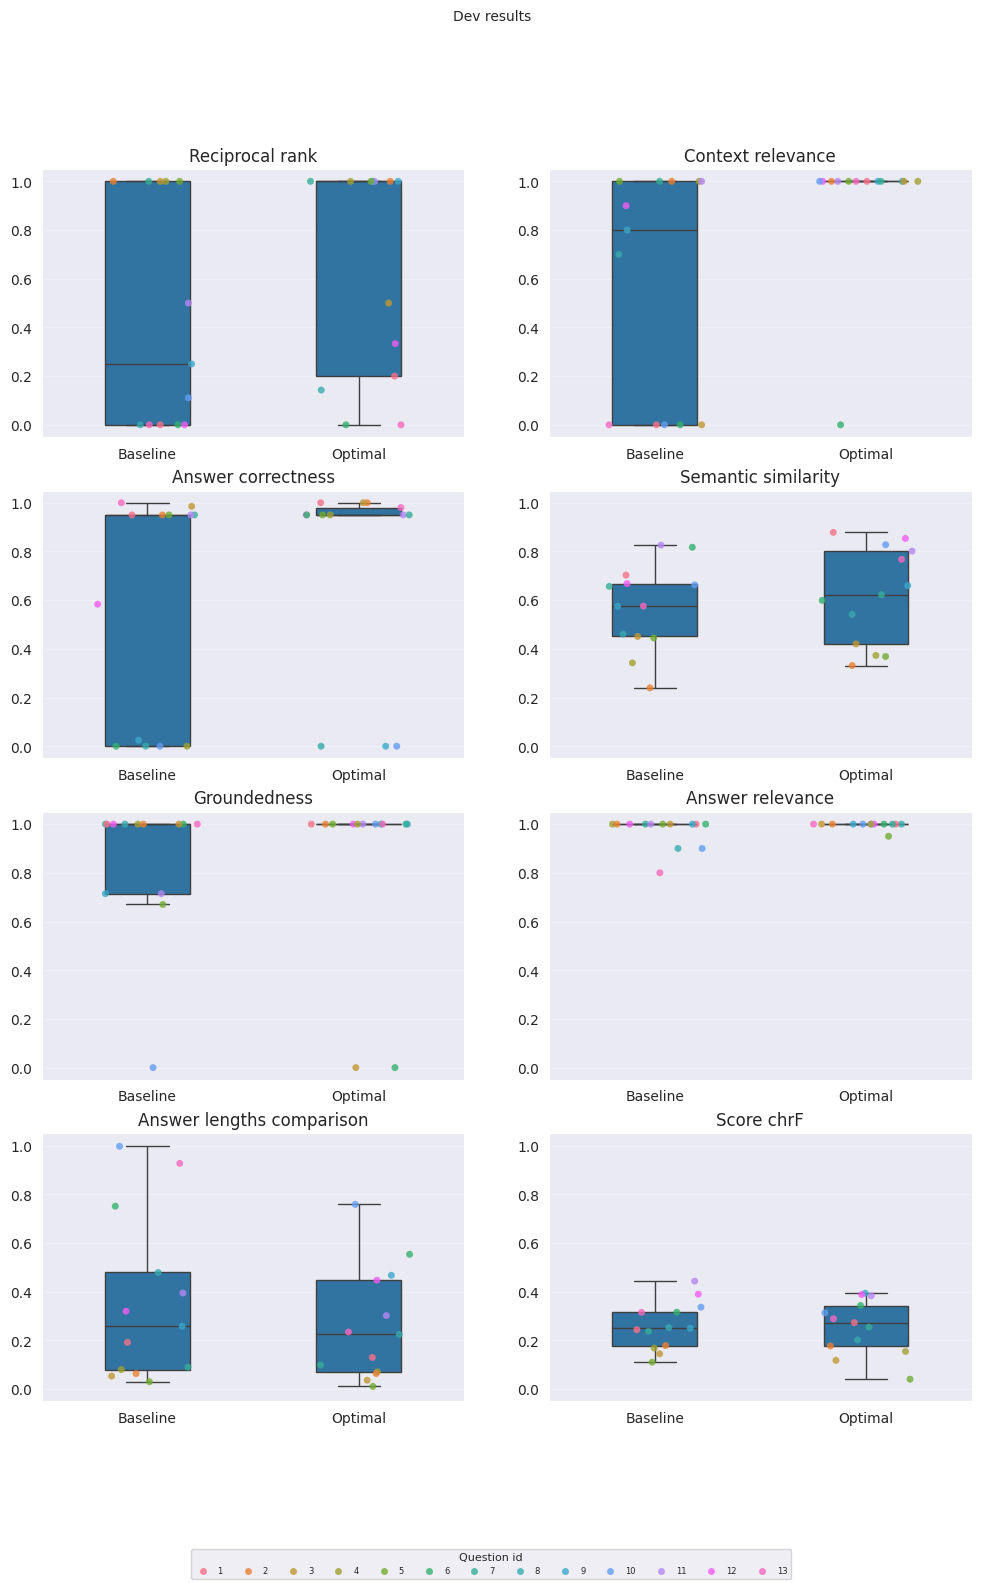

In [11]:
plot_metrics_for_split(
    dataset_type="Dev",
    baseline_df=add_question_id_and_reorder_df(df_dev_baseline, "dev"),
    optimal_df=add_question_id_and_reorder_df(df_dev_optimal, "dev")
)

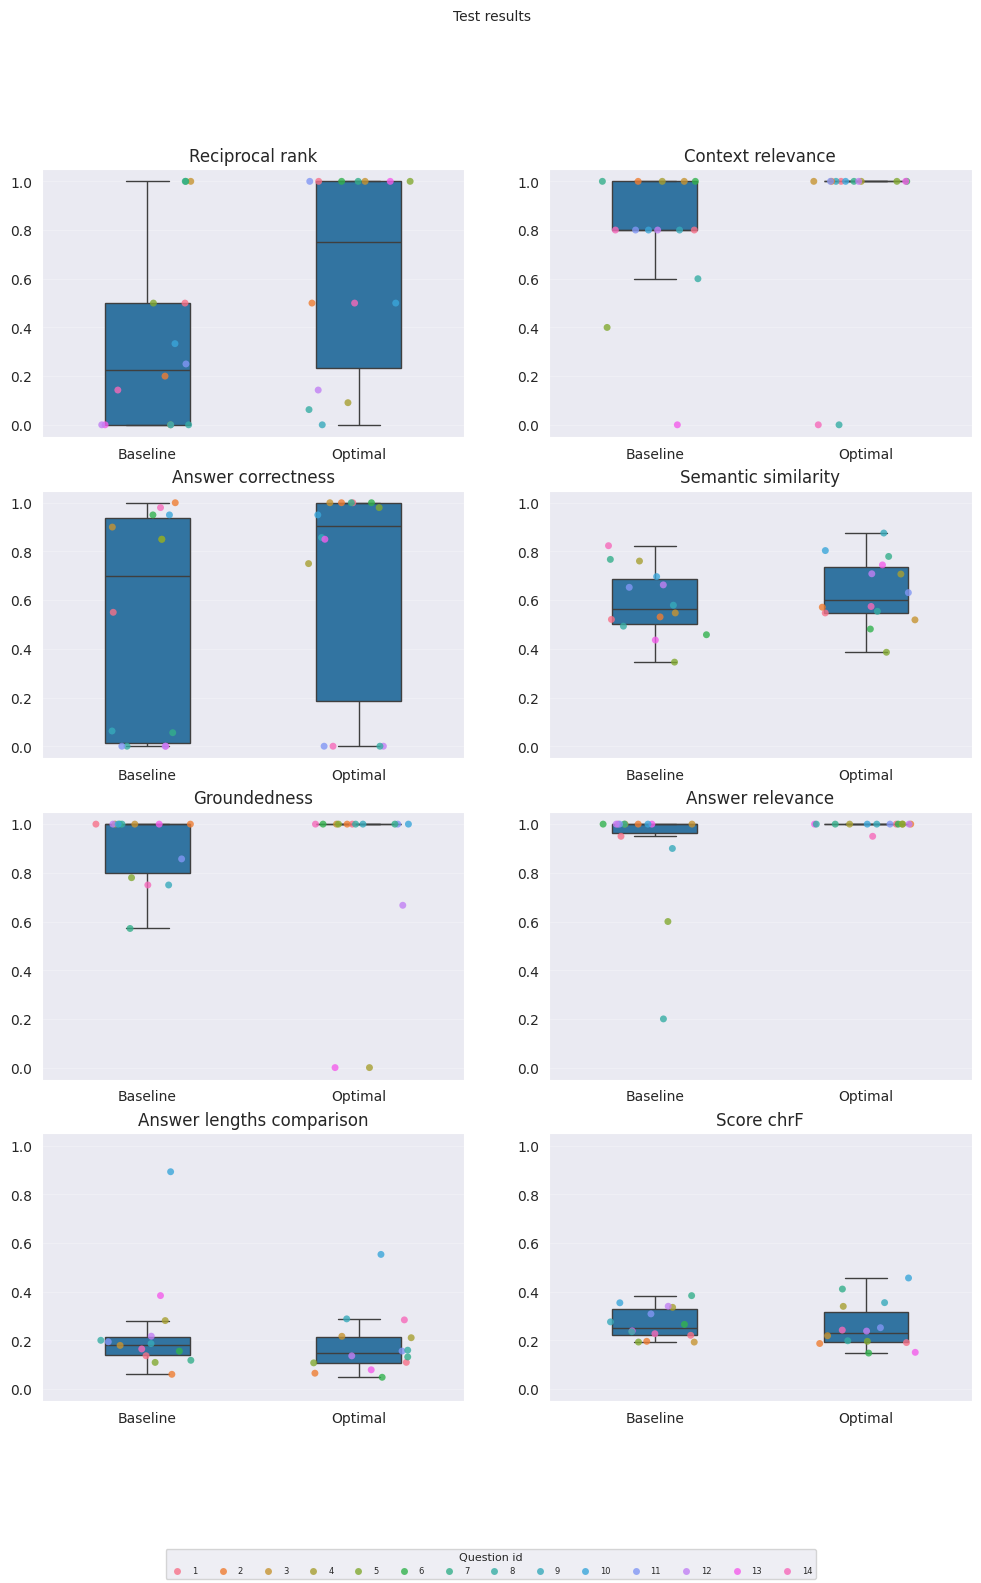

In [12]:
plot_metrics_for_split(
        dataset_type="Test",
        baseline_df=add_question_id_and_reorder_df(df_test_baseline, "test"),
        optimal_df=add_question_id_and_reorder_df(df_test_optimal, "test")
)